In [7]:
!pip install opencv-python
import cv2
import numpy as np

In [8]:
image=cv2.imread("/content/56.PNG")

In [9]:
from google.colab.patches import cv2_imshow



Original Image:


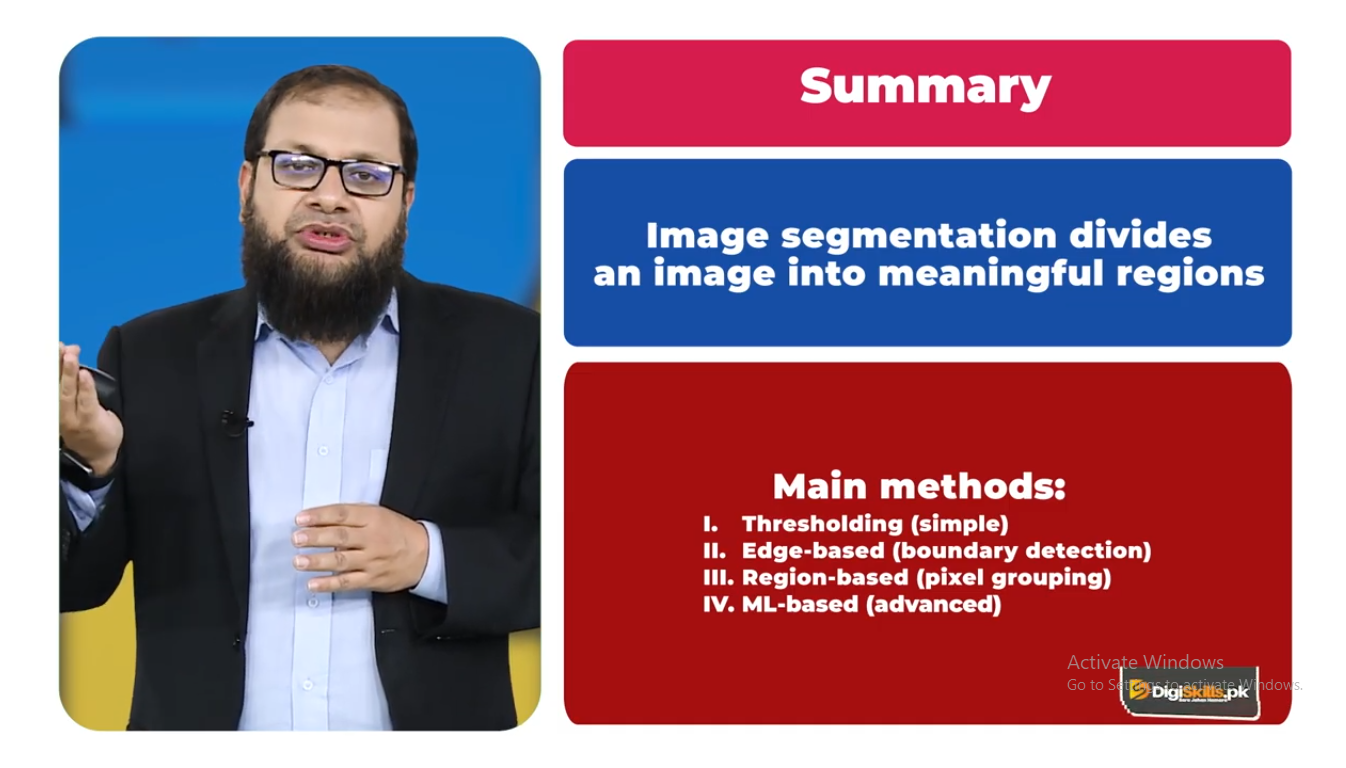

Gray Image:


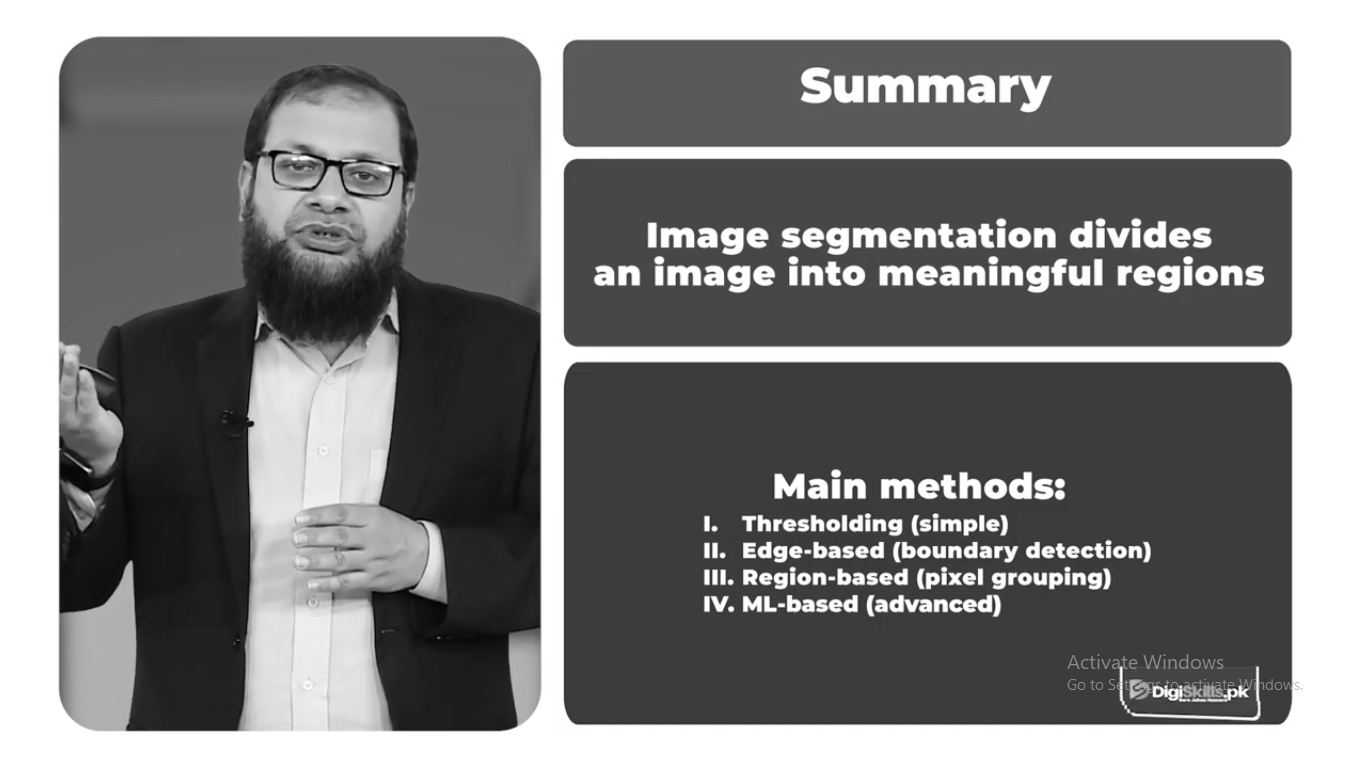

In [10]:
if image is None:
  print("Image is not found! Please check the file path in the previous cell.")
else:
  print("Original Image:")
  cv2_imshow(image)
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  print("Gray Image:")
  cv2_imshow(gray)

Image Filtering (Noise Reomaovel)

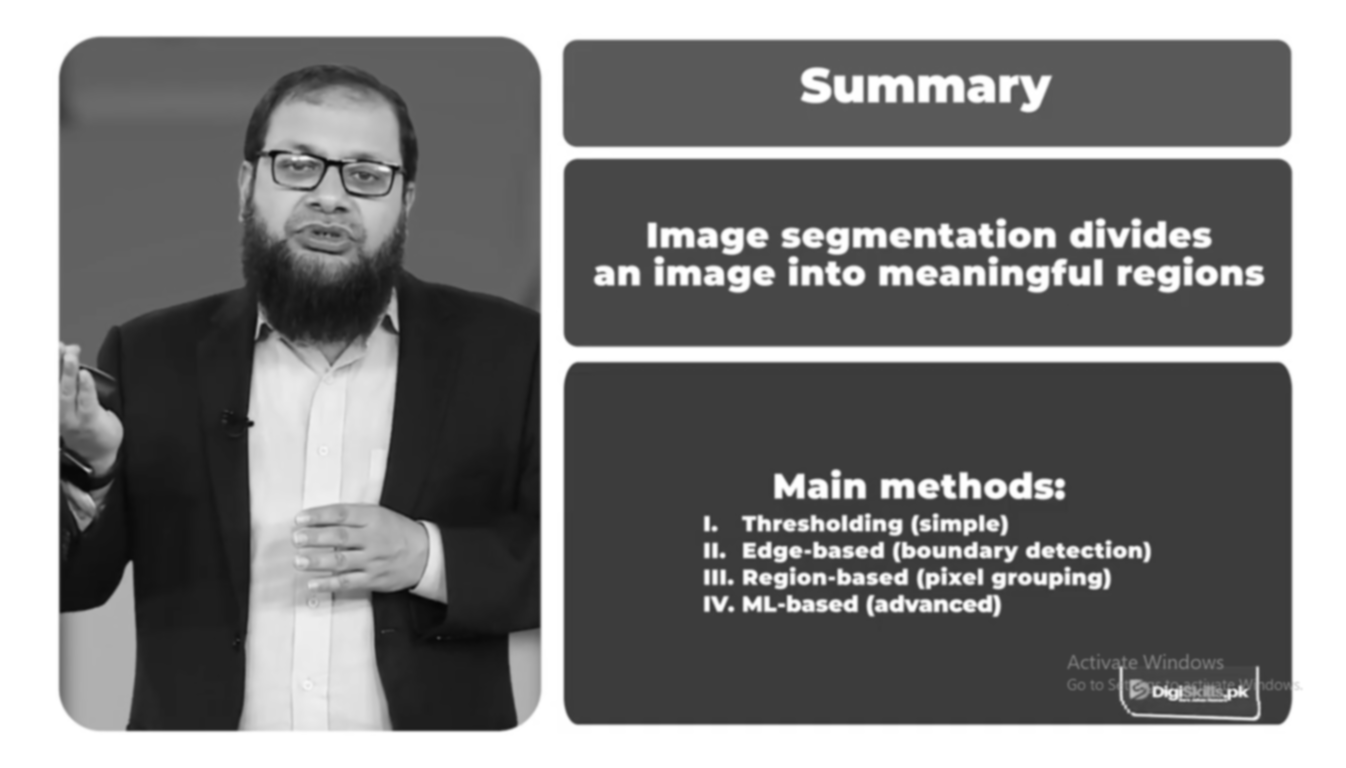

In [11]:
blur = cv2.GaussianBlur(gray, (5, 5), 0)
cv2_imshow(blur)

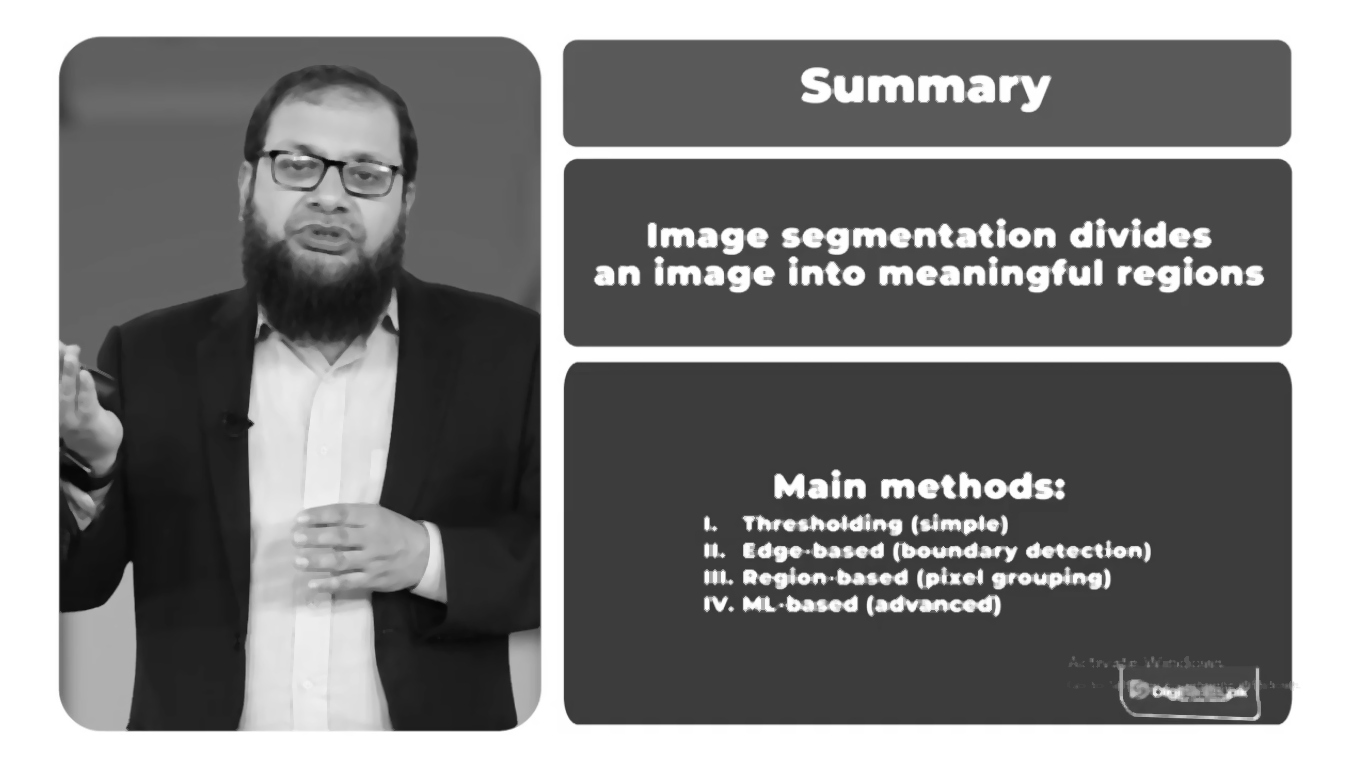

In [12]:
medain=cv2.medianBlur(gray,5)
cv2_imshow(medain)

Edge Detection

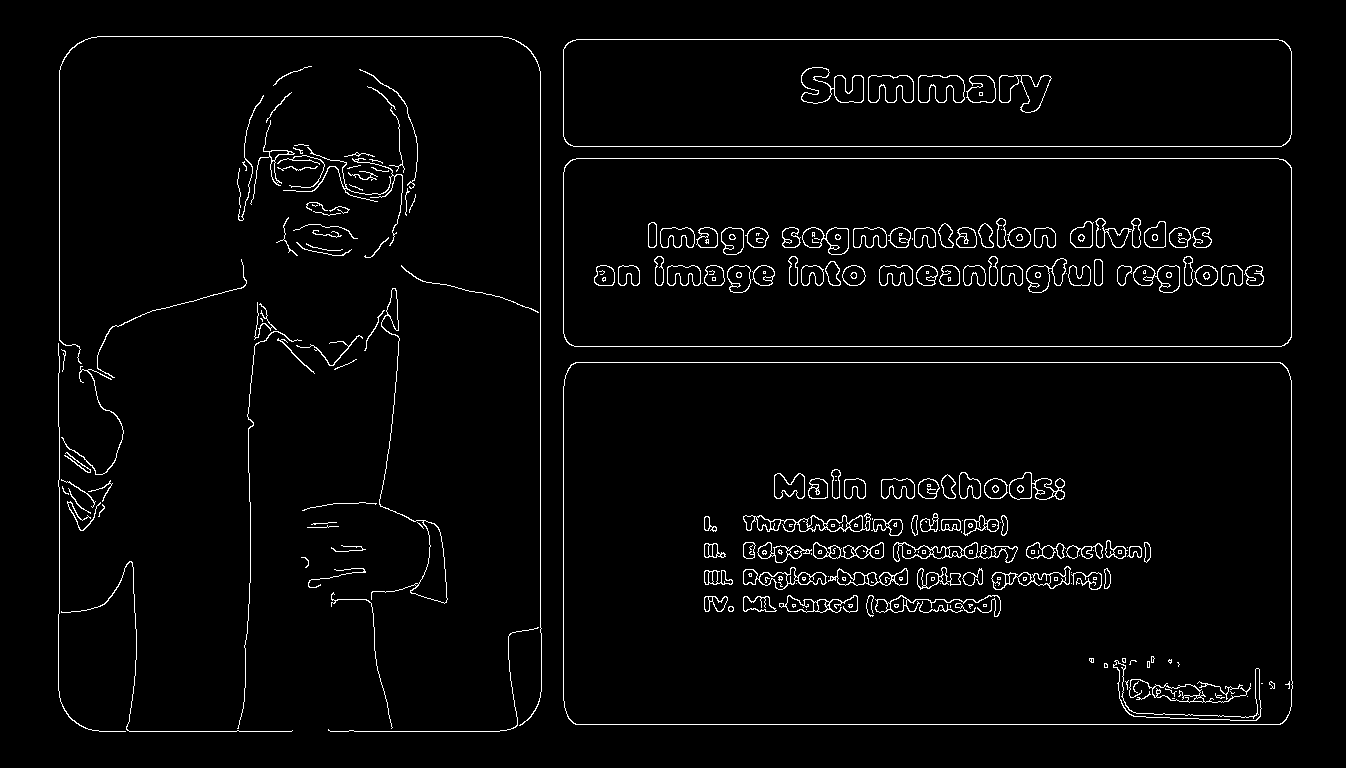

In [13]:
edges=cv2.Canny(medain,100,200)
cv2_imshow(edges)
#

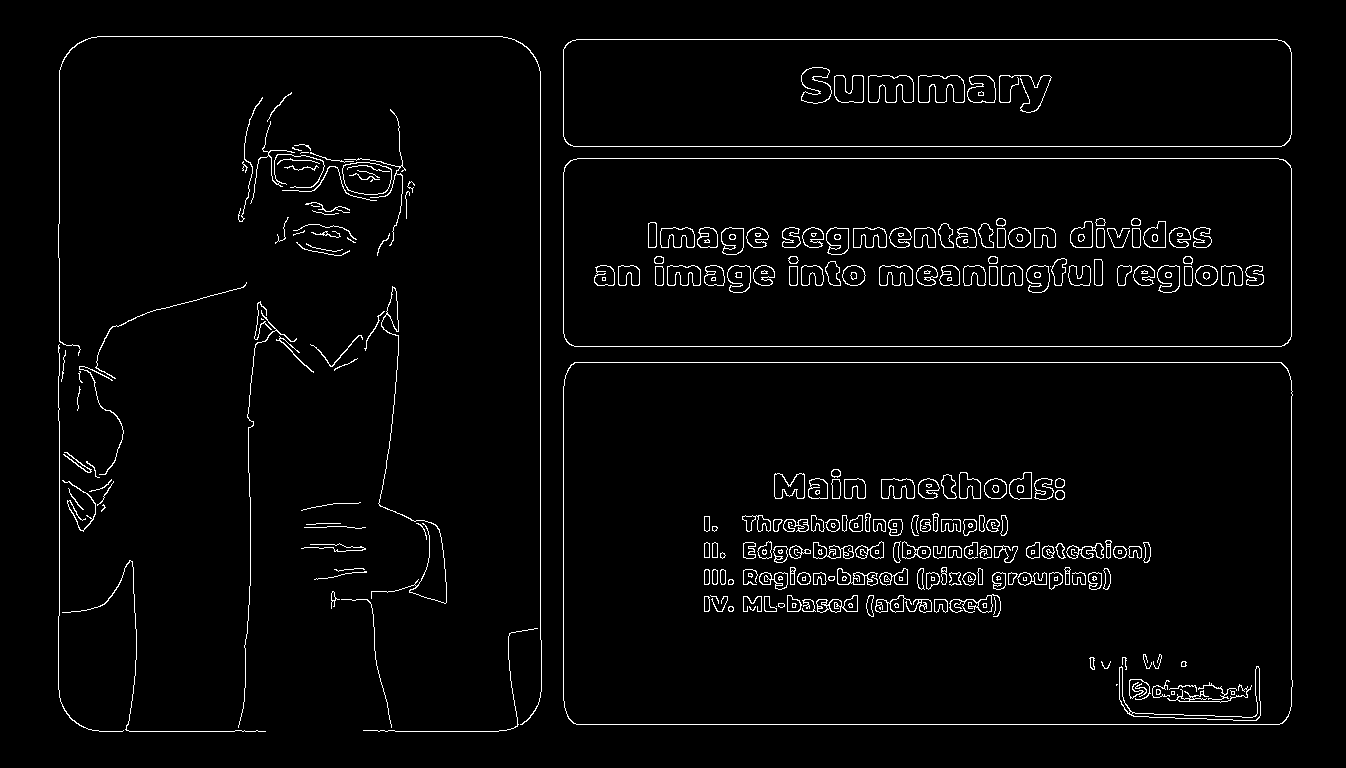

In [14]:
edges1=cv2.Canny(blur,100,200)
cv2_imshow(edges1)
#

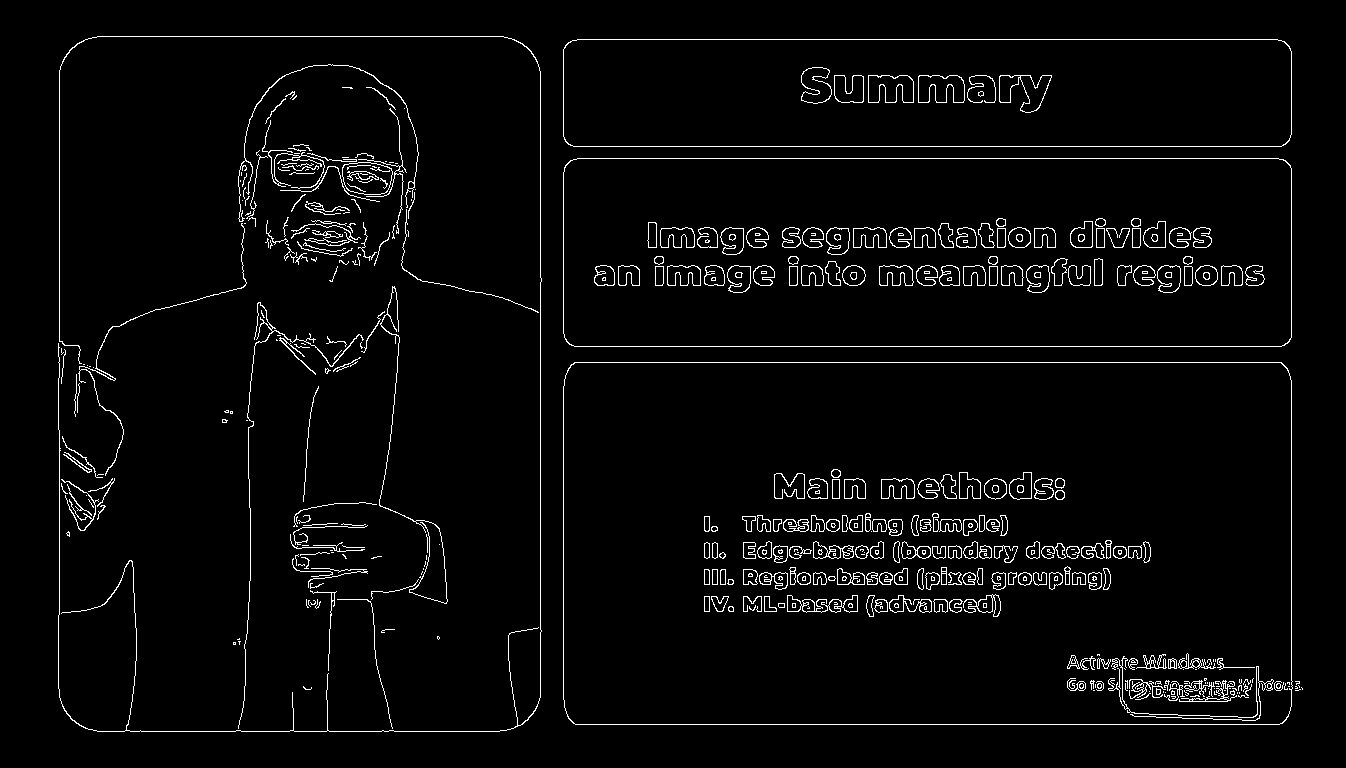

In [15]:
edges2=cv2.Canny(image,100,200)
cv2_imshow(edges2)
#

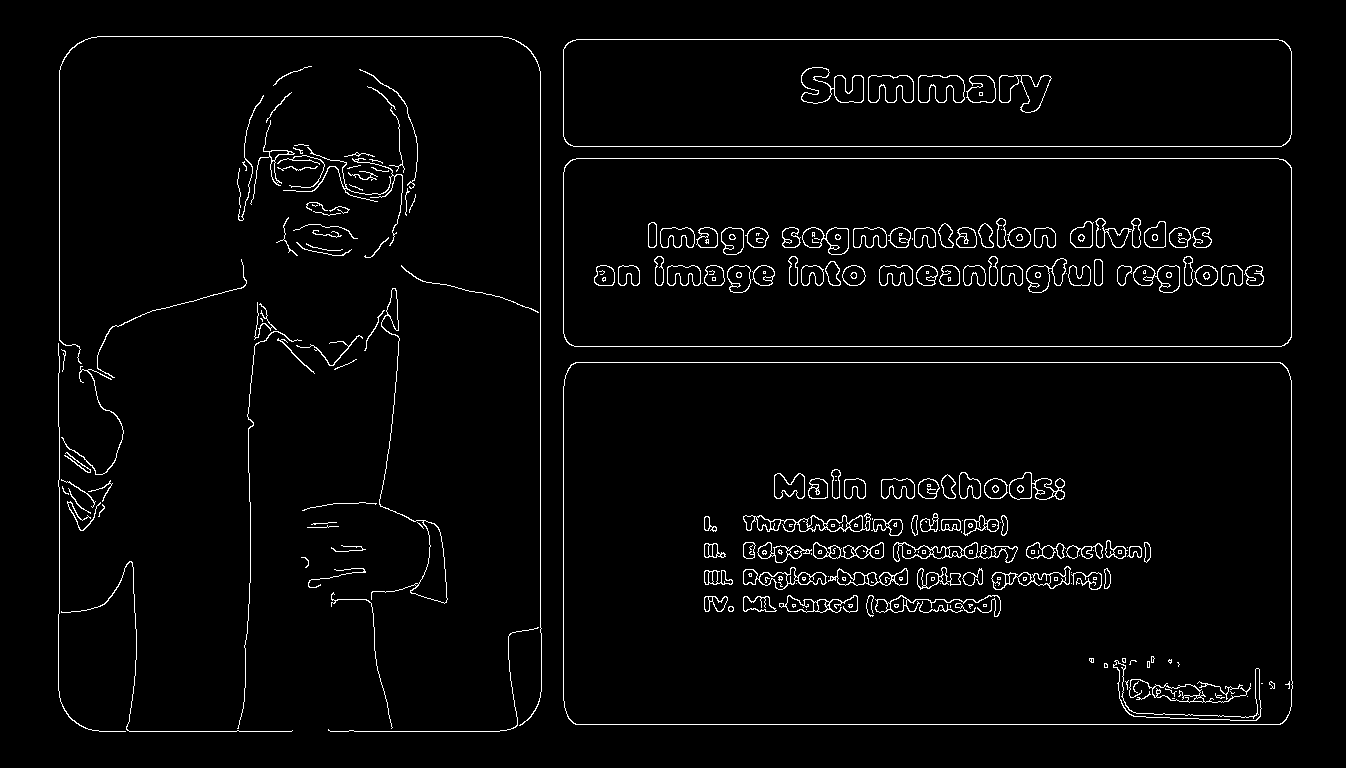

In [16]:
edges3=cv2.Canny(medain,100,200)
cv2_imshow(edges3)
#

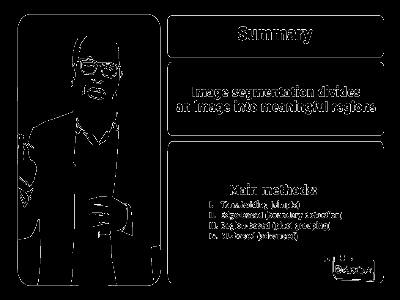

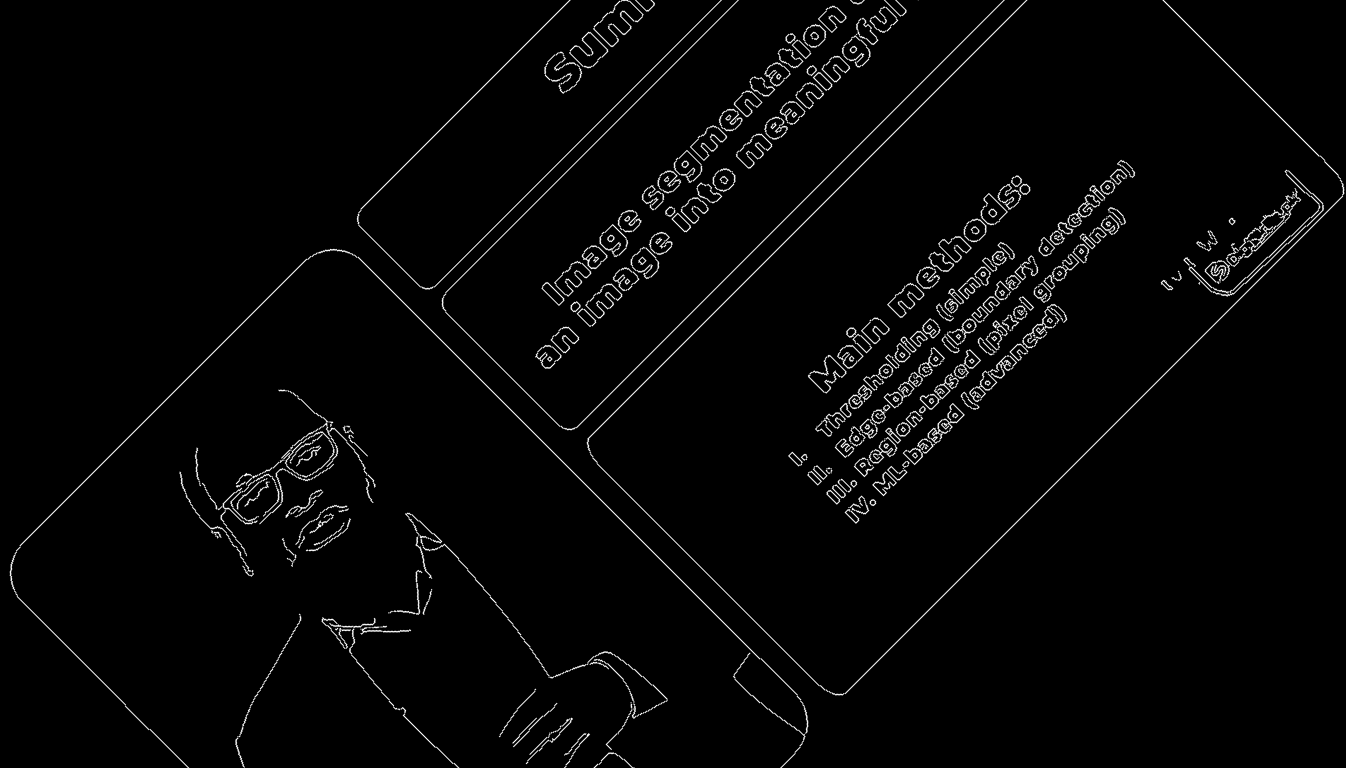

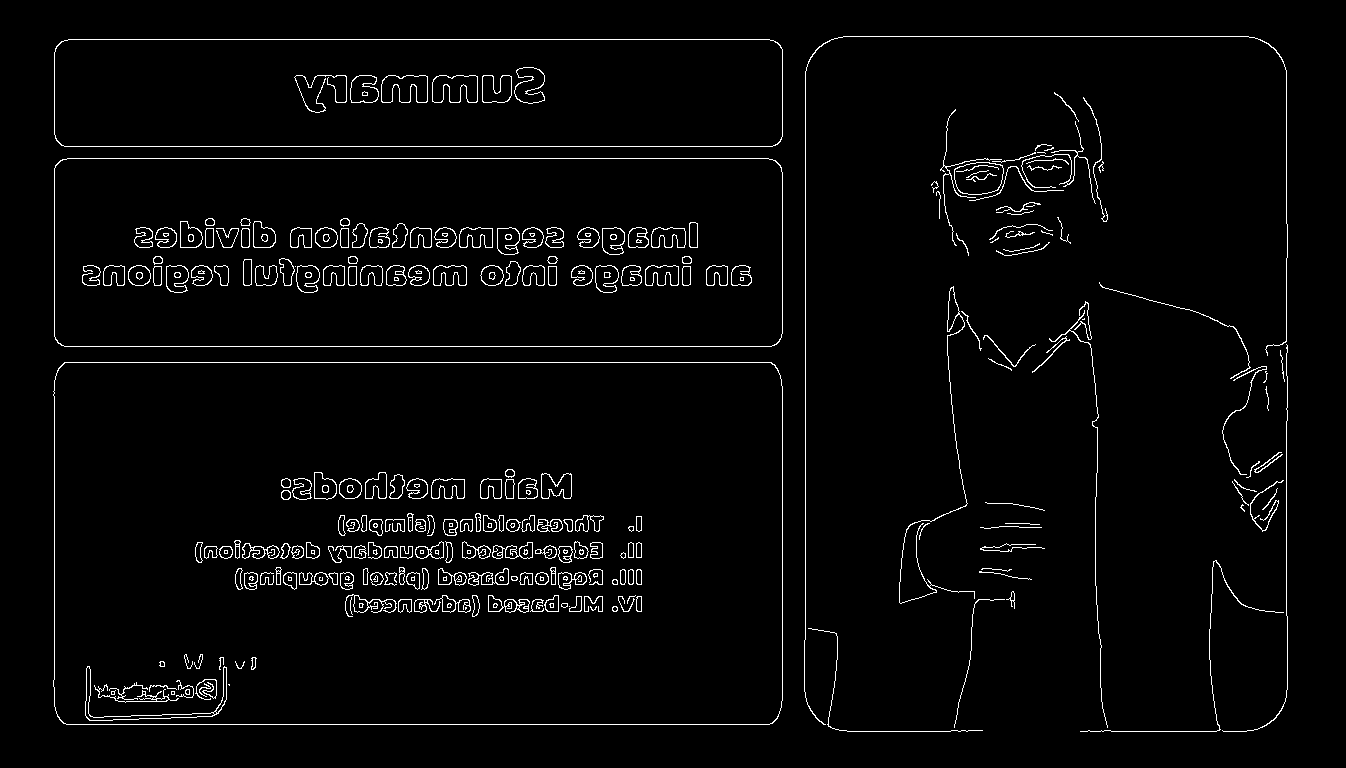

In [17]:
resized=cv2.resize(edges1,(400,300))
cv2_imshow(resized)

hight,width=edges1.shape[:2]
center=(width/2,hight/2)
rotation_matrix=cv2.getRotationMatrix2D(center=center,angle=45,scale=1)
rotated=cv2.warpAffine(src=edges1,M=rotation_matrix,dsize=(width,hight))
cv2_imshow(rotated)

flipped=cv2.flip(edges1,flipCode=1)
cv2_imshow(flipped)


In [20]:
cv2.imwrite("edges_output.jpg",edges1)

True

Project No 1

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [6]:
import numpy as np
import cv2

img_size = 128
img_class = 1

def create_datasets(samples=200):
    images = []
    labels = []

    for _ in range(samples):

        # Black image
        img = np.zeros((img_size, img_size, 3), dtype=np.uint8)

        # Random rectangle position and size
        x = np.random.randint(20, 90)
        y = np.random.randint(20, 90)

        w = np.random.randint(20, 30)
        h = np.random.randint(20, 30)

        # Draw white rectangle
        cv2.rectangle(
            img,
            (x, y),
            (x + w, y + h),
            (255, 255, 255),
            -1
        )

        # Normalized center coordinates
        x_center = (x + w / 2) / img_size
        y_center = (y + h / 2) / img_size

        # Normalized width and height
        w_norm = w / img_size
        h_norm = h / img_size

        images.append(img / 255.0)

        labels.append([
            x_center,
            y_center,
            w_norm,
            h_norm,
            img_class
        ])

    return np.array(images), np.array(labels)


X, y = create_datasets()

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

print("\nFirst Label:")
print(y[0])

Images Shape: (200, 128, 128, 3)
Labels Shape: (200, 5)

First Label:
[0.7578125  0.69921875 0.171875   0.1953125  1.        ]


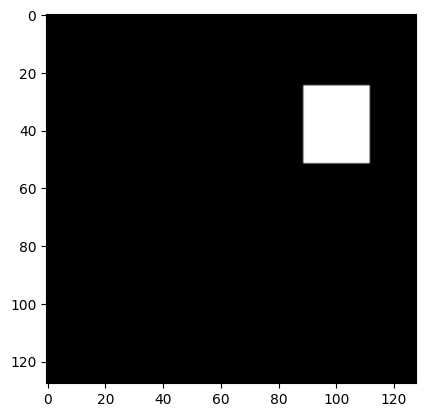

In [10]:
plt.imshow(X[3])
plt.show()

In [12]:
split=int(len(X)*0.8)
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense

model=Sequential([
    Conv2D(16,(3,3),activation='relu',input_shape=(img_size,img_size,3)),
    MaxPooling2D(),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(5,activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,989 (6.22 MB)

 Trainable params: 1,629,989 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [16]:
history=model.fit(
    X_train,y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 285ms/step - accuracy: 0.7578 - loss: 3.9485 - val_accuracy: 1.0000 - val_loss: 6.2419
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 9.1826 - val_accuracy: 0.9062 - val_loss: 14.1022
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8281 - loss: 21.1125 - val_accuracy: 0.8750 - val_loss: 37.4719
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9766 - loss: 54.4996 - val_accuracy: 0.9062 - val_loss: 94.2610
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8203 - loss: 130.8748 - val_accuracy: 0.6250 - val_loss: 222.6669
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9062 - loss: 303.4091 - val_accuracy: 1.0000 - val_loss: 502.6270
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9062 - loss: 647.0183 - val_accuracy: 0.8125 - val_loss: 1016.9824
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9219 - loss: 1302.0049 - val_accuracy: 0.75

In [17]:
acc,loss=model.evaluate(X_test,y_test)
print("Accuracy:",acc)
print("Loss:",loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step - accuracy: 0.9500 - loss: 6004.3550
Accuracy: 6004.35498046875
Loss: 0.949999988079071
